# Figure 1

### Load Difficulty Result

In [1]:
diff_idx = input("INPUT 'visualization_target for difficulty RUN_ID'(e.g., 111110000): ")

print(f'Figure will be drawn based on the run_id_{diff_idx} dataset')

Figure will be drawn based on the run_id_111110000 dataset


In [2]:
complexity_idx = input("INPUT 'visualization_target for complexity RUN_ID'(e.g., 20000): ")

print(f'Figure will be drawn based on the run_id_{complexity_idx} dataset')

Figure will be drawn based on the run_id_20000 dataset


In [3]:
import pandas as pd
import numpy as np
from datetime import datetime
import os
from glob import glob


from lib.annotation.tools.Result_Prep import Result_Prep as Result_Prep_D
from lib.code_complexity.tools.Result_Prep import Result_Prep as Result_Prep_C

import lib.stats.stats as st
from lib.utils.file_io import *
from lib.utils.statistics import *
from lib.utils.settings import set_matplotlib
from matplotlib import pyplot as plt
import matplotlib as mpl
from lib.visualization.plot_generator import PlotGen
import lib.visualization.figure_setting as figure_setting

mpl.rcParams.update(figure_setting.fig_setting)
# mpl.rcParams['font.family'] = figure_setting.init_font()



In [ ]:
rp_prep_diff = Result_Prep_D(diff_idx)
diff_df = rp_prep_diff.data_prep()

In [5]:
rp_prep_comp = Result_Prep_C(complexity_idx)
comp_df = rp_prep_comp.data_prep()

100%|██████████| 65/65 [00:12<00:00,  5.11it/s]


In [6]:
def draw_complexity_regression(ax, x, y, st_chow,
                               F_stat_1, p_value_1, title,
                               panel_label=''):

    split_idx = np.where(x < 0)[0][-1] + 1
    x1 = x[:split_idx]
    x2 = x[split_idx:]

    # ── scatter plot 
    plot_gen = PlotGen()
    plot_gen.draw_scatter_plot(ax, x, y)

    # ── Overall fit 
    plot_gen.draw_line_plot(ax, x, st_chow.y_predict, label='Overall fit', color=figure_setting.PALETTE['neutral'])

    # ── Before ChatGPT
    plot_gen.fill_confidence_interval(ax, x1, st_chow.y1_predict - st_chow.y1_conf_interval, st_chow.y1_predict + st_chow.y1_conf_interval
                                          , label=None, color = figure_setting.PALETTE['primary'])
    plot_gen.draw_line_plot(ax, x1, st_chow.y1_predict, label='Before ChatGPT', color=figure_setting.PALETTE['primary'])

    # ── After ChatGPT
    plot_gen.fill_confidence_interval(ax, x2, st_chow.y2_predict - st_chow.y2_conf_interval, st_chow.y2_predict + st_chow.y2_conf_interval
                                          , label=None, color = figure_setting.PALETTE['accent'])
    plot_gen.draw_line_plot(ax, x2, st_chow.y2_predict,
            label='After ChatGPT',
            color=figure_setting.PALETTE['accent'])

    # ── virtical line for chatGPT release
    plot_gen.draw_vertical_line(ax, x=0, label=None)


    # ── set title with p-value
    plot_gen.set_title(ax, prefix = panel_label, title_text = title, p_value = p_value_1)

    # ── ticks
    plot_gen.set_ticks(ax)

    # ── set x lim
    plot_gen.set_lims(ax, x, y)

Basic 35.4752395760304
Intermediate 27.275201145903782
Advanced 49.984627865602164
4.144527980372589


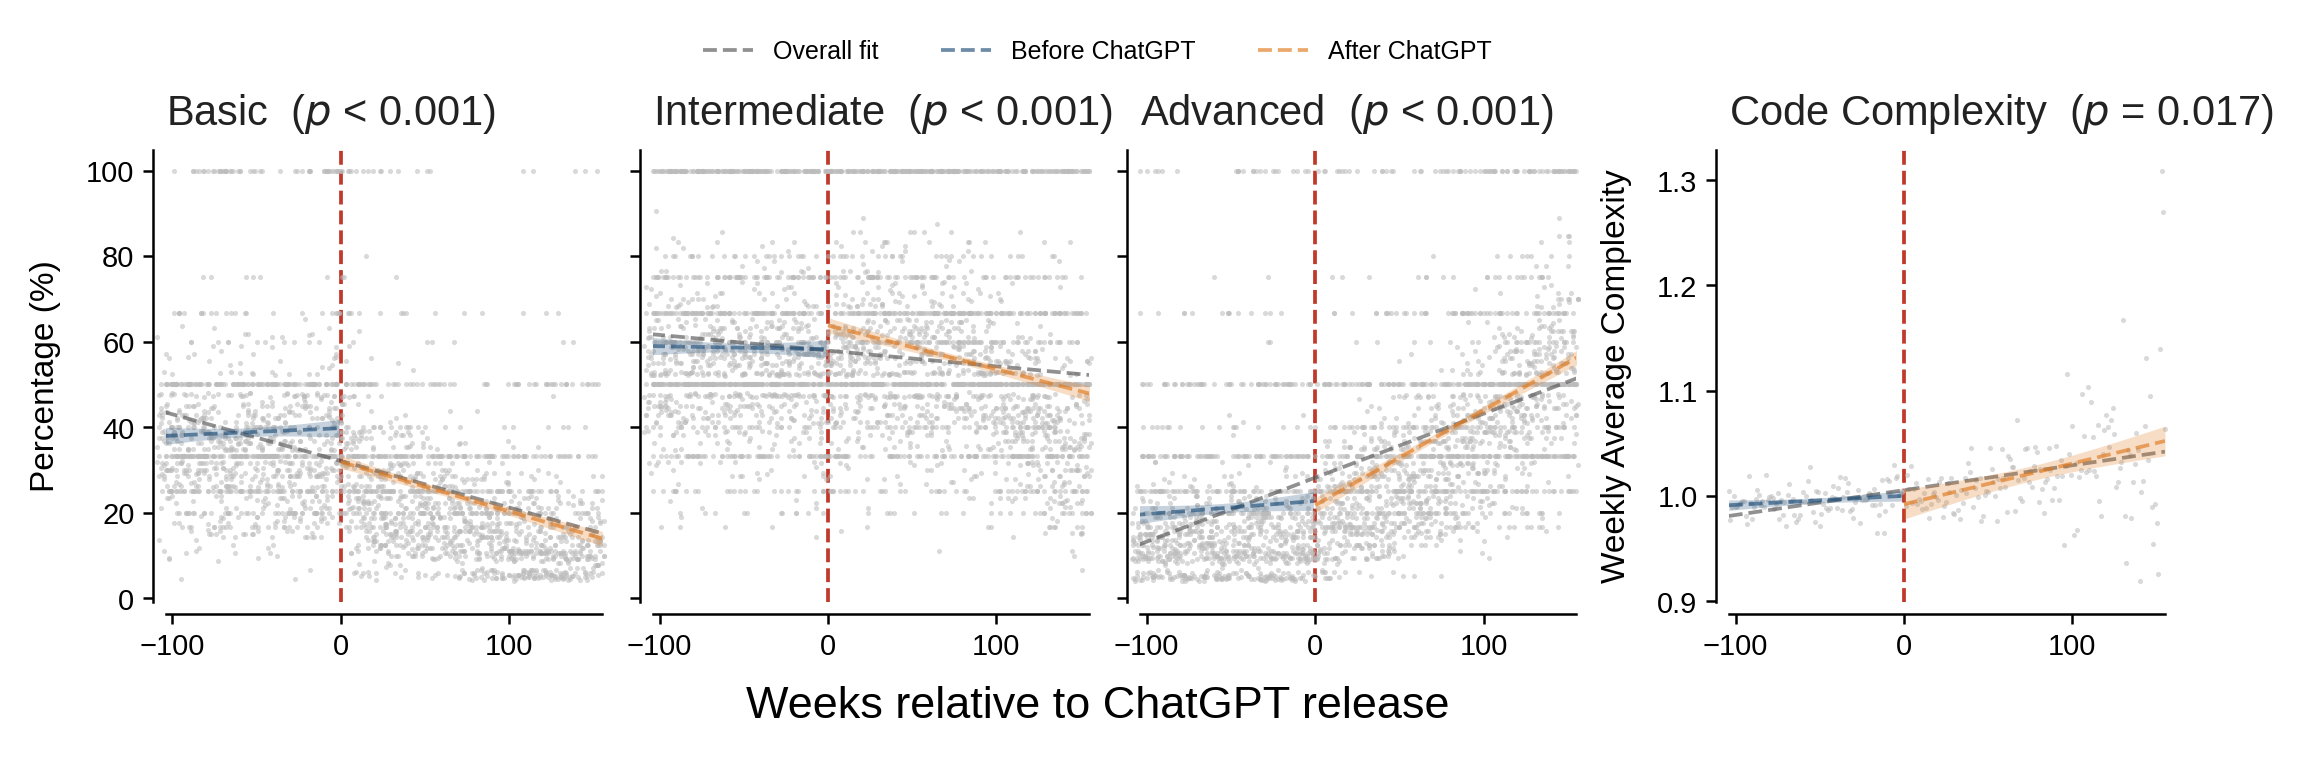

In [7]:
fig, axes = plt.subplots(1, 4,
                        figsize=(7.2, 2.2),
                        constrained_layout=True,
                        dpi=300,
                        sharex=True
                    )
# draw question's difficulty related panels
label_dict = {'A': 'Basic', 'B': 'Intermediate', 'C': 'Advanced'}

for i, (label, title) in enumerate(label_dict.items()):
    chk_cnt = diff_df[diff_df['o_result'] == str(i)].sort_values(
        by=['rel_week'], ascending=True).reset_index(drop=True)
    x = chk_cnt['rel_week'].values
    y = chk_cnt['rate'].values

    st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
    F_stat, p_value = st_chow.chow_test()
    draw_complexity_regression(
        axes[i], x, y, st_chow, F_stat, p_value,
        title=f"{title}", panel_label=""
    )
    print(title, F_stat)

y_min = min(ax.get_ylim()[0] for ax in axes[:3])
y_max = max(ax.get_ylim()[1] for ax in axes[:3])
for ax in axes[:3]:
    ax.set_ylim(y_min, y_max)


for ax in axes[1:3]:
    ax.tick_params(labelleft=False)

# draw complexity related panels
chk_cnt = comp_df.sort_values(by=['rel_week'], ascending=True).reset_index(drop=True)
x = chk_cnt['rel_week'].values
y = chk_cnt['cyclomatic_complexity'].values

st_chow = st.Stats(x, y, 0.95, np.where(x < 0)[0][-1] + 1)
F_stat, p_value = st_chow.chow_test()
draw_complexity_regression(
    axes[-1], x, y, st_chow, F_stat, p_value,
    title="Code Complexity", panel_label=""
)
print(F_stat)

axes[-1].set_ylabel("Weekly Average Complexity", labelpad=6)

fig.supxlabel("Weeks relative to ChatGPT release")

axes[0].set_ylabel("Percentage (%)", labelpad=6)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc='lower center',
    bbox_to_anchor=(0.5, 0.99),
    ncol=3, frameon=False,
    handlelength=2.0, columnspacing=2.5
)
plt.savefig('./fig/Fig1.pdf', bbox_inches='tight', dpi=300)